## Mission 2

- 미션 2. 신고자/119 대원 분류하기: 한 사람의 한 발화 조각을 통해 신고자와 119 대원 분류
  - 발화 조각 경계는 annotation의 `utterances` 배열 항목(대화가 끊기는 지점 기준)을 그대로 사용
  - **음성으로만 분류 (annotation, text 사용 불가)**: `speaker`(정답 라벨), `text`는 학습 타겟/사람이 읽는 용도로만 쓰고, 모델 입력 특징에는 절대 포함하지 않음
  - **발화 등장 순서(홀짝)로 분류 금지**: 모델 입력에 순서/위치 정보를 일절 사용하지 않음. 학습 후 홀짝 추정 베이스라인과 성능을 비교해 검증 (12번 섹션)
  - 공통 규정: 외부 데이터/API 사용 불가(공개 pretrained 모델 다운로드 후 자체 fine-tuning은 허용, FAQ Q1 확인됨), 서울권 데이터만 사용, Validation은 검증 목적으로만 사용, 주석 필수
- **팀 backbone 비교 축**: wav2vec2.0 / WavLM / AST 중 **본인 담당은 AST(Audio Spectrogram Transformer)**. 팀 비교표에 SmallCNN 자리는 없어서, 이 노트북은 AST만 다룹니다.
- References: 성능 평가 진행, 학습 모델 + 추론 코드 함께 제출


### 0. GPU 확인

In [9]:
!nvidia-smi


Mon Sep 14 11:58:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 1. 환경 설정

In [11]:
# ===== 환경 설정 =====
IS_DRIVE = True

if IS_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

!pip install -q librosa soundfile scikit-learn transformers

import os, json, shutil, random, time
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score
from transformers import ASTFeatureExtractor, ASTForAudioClassification

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={device}, GPU={torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
if device.type == "cpu":
    print("⚠️ GPU 미검출 — AST는 CPU로 학습 시 매우 오래 걸립니다. 런타임 유형을 GPU로 바꿔주세요.")

DRIVE_ROOT = ("/content/drive/MyDrive/projects/AI-DCC/mission1-data" if IS_DRIVE
              else os.path.join(os.path.expanduser("~"), "Downloads", "mission1-data"))

AST_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"  # HuggingFace 공개 pretrained (FAQ Q1: 다운로드+fine-tuning 허용)

CONFIG = {
    "train_audio_root": os.path.join(DRIVE_ROOT, "Training", "1.원천데이터", "TS_서울_구급"),
    "train_label_root": os.path.join(DRIVE_ROOT, "Training", "2.라벨링데이터", "TL_서울_구급"),
    "val_audio_root":   os.path.join(DRIVE_ROOT, "Validation", "1.원천데이터", "VS_서울_구급"),
    "val_label_root":   os.path.join(DRIVE_ROOT, "Validation", "2.라벨링데이터", "VL_서울_구급"),

    "local_json_dir": "/content/mission2_local_json",
    "local_audio_dir": "/content/mission2_local_audio",
    "ast_cache_dir": "/content/mission2_ast_cache",
    "checkpoint_dir": (os.path.join(DRIVE_ROOT, "checkpoints_mission2") if IS_DRIVE
                        else "/content/mission2_checkpoints"),

    "sample_rate": None,
    "ast_sample_rate": 16000,

    "subsample_frac": 0.08,   # 전체 89만 건은 비현실적으로 오래 걸려서 우선 15%만 사용 (4b번 셀에서 적용)

    "ast_batch_size": 16,
    "epochs": 30,
    "lr_ast": 5e-5,
    "early_stop_patience": 5,
}
os.makedirs(CONFIG["ast_cache_dir"], exist_ok=True)
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device=cuda, GPU=Tesla T4


### 2. 실제 샘플레이트 확인

In [12]:
def find_one_wav(root):
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if f.endswith(".wav"):
                return os.path.join(dirpath, f)
    return None

sample_wav = find_one_wav(CONFIG["train_audio_root"])
if sample_wav is None:
    raise FileNotFoundError(f"wav 파일을 찾지 못했습니다: {CONFIG['train_audio_root']}")

info = sf.info(sample_wav)
print(f"샘플 파일: {sample_wav}")
print(f"원본 샘플레이트: {info.samplerate}Hz (AST 입력 시 {CONFIG['ast_sample_rate']}Hz로 업샘플링됨)")
CONFIG["sample_rate"] = info.samplerate


샘플 파일: /content/drive/MyDrive/projects/AI-DCC/mission1-data/Training/1.원천데이터/TS_서울_구급/651e553ba8f14bddba4c1312_20220603.wav
원본 샘플레이트: 8000Hz (AST 입력 시 16000Hz로 업샘플링됨)


### 3. 라벨링(JSON) 데이터 로컬 복사

In [13]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def copy_one_file(src_path, dst_path, max_retries=3):
    if os.path.exists(dst_path) and os.path.getsize(dst_path) == os.path.getsize(src_path):
        return True, None
    for attempt in range(max_retries):
        try:
            shutil.copy(src_path, dst_path)
            return True, None
        except OSError as e:
            if attempt == max_retries - 1:
                return False, str(e)

def copy_json_tree(src_root, dst_root, max_workers=16):
    os.makedirs(dst_root, exist_ok=True)

    # 디렉토리 구조부터 만들고, 복사할 (원본, 대상) 쌍만 먼저 목록화
    tasks = []
    for dirpath, _, filenames in os.walk(src_root):
        rel_dir = os.path.relpath(dirpath, src_root)
        dst_dir = os.path.join(dst_root, rel_dir)
        os.makedirs(dst_dir, exist_ok=True)
        for fname in filenames:
            tasks.append((os.path.join(dirpath, fname), os.path.join(dst_dir, fname)))

    if len(tasks) == 0:
        raise RuntimeError(f"{src_root} 에서 파일을 하나도 찾지 못했습니다. 이 셀을 다시 실행해보세요.")

    print(f"{src_root}: {len(tasks)}개 파일 복사 시작 (병렬 {max_workers}개)")
    failed = []
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(copy_one_file, s, d): s for s, d in tasks}
        for i, future in enumerate(as_completed(futures)):
            ok, err = future.result()
            if not ok:
                failed.append((futures[future], err))
            if (i + 1) % 2000 == 0:
                elapsed = time.time() - t0
                speed = (i + 1) / elapsed
                remaining_min = (len(tasks) - (i + 1)) / speed / 60
                print(f"  {i+1}/{len(tasks)} | 경과 {elapsed/60:.1f}분 | 남은 예상 {remaining_min:.1f}분")

    if failed:
        print(f"\n⚠️ {len(failed)}개 파일 복사 실패 — 다시 실행하면 나머지만 이어서 복사합니다.")
    else:
        print(f"복사 완료: {src_root} -> {dst_root} ({len(tasks)}개 파일, {(time.time()-t0)/60:.1f}분 소요)")


local_train_label = os.path.join(CONFIG["local_json_dir"], "train")
local_val_label = os.path.join(CONFIG["local_json_dir"], "val")
copy_json_tree(CONFIG["train_label_root"], local_train_label)
copy_json_tree(CONFIG["val_label_root"], local_val_label)

/content/drive/MyDrive/projects/AI-DCC/mission1-data/Training/2.라벨링데이터/TL_서울_구급: 29200개 파일 복사 시작 (병렬 16개)
  2000/29200 | 경과 9.2분 | 남은 예상 124.6분
  4000/29200 | 경과 9.2분 | 남은 예상 58.1분
  6000/29200 | 경과 9.3분 | 남은 예상 35.9분
  8000/29200 | 경과 9.4분 | 남은 예상 24.8분
  10000/29200 | 경과 9.4분 | 남은 예상 18.1분
  12000/29200 | 경과 9.5분 | 남은 예상 13.6분
  14000/29200 | 경과 9.6분 | 남은 예상 10.4분
  16000/29200 | 경과 9.6분 | 남은 예상 7.9분
  18000/29200 | 경과 9.7분 | 남은 예상 6.0분
  20000/29200 | 경과 9.8분 | 남은 예상 4.5분
  22000/29200 | 경과 9.9분 | 남은 예상 3.2분
  24000/29200 | 경과 9.9분 | 남은 예상 2.1분
  26000/29200 | 경과 10.0분 | 남은 예상 1.2분
  28000/29200 | 경과 10.1분 | 남은 예상 0.4분
복사 완료: /content/drive/MyDrive/projects/AI-DCC/mission1-data/Training/2.라벨링데이터/TL_서울_구급 -> /content/mission2_local_json/train (29200개 파일, 10.1분 소요)
/content/drive/MyDrive/projects/AI-DCC/mission1-data/Validation/2.라벨링데이터/VL_서울_구급: 3640개 파일 복사 시작 (병렬 16개)
  2000/3640 | 경과 0.9분 | 남은 예상 0.7분
복사 완료: /content/drive/MyDrive/projects/AI-DCC/mission1-data/Validation/2.라벨링데이터/V

### 4. Manifest 생성 (신고자 + 119대원 발화 전체, role 라벨)

In [14]:
def build_audio_index(audio_root):
    index = {}
    for dirpath, _, filenames in os.walk(audio_root):
        for fname in filenames:
            if not fname.lower().endswith(".wav"):
                continue
            file_id = os.path.splitext(fname)[0].split("_")[0]
            index[file_id] = os.path.join(dirpath, fname)
    return index


def parse_one_json(json_path, audio_index):
    with open(json_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    file_id = meta.get("_id") or meta.get("recordId")
    call_id = meta.get("recordId") or file_id or os.path.splitext(os.path.basename(json_path))[0]
    utterances = meta.get("utterances", meta.get("utterences", []))

    audio_path = audio_index.get(file_id)
    if audio_path is None:
        return []

    records = []
    for utt in utterances:
        role = utt.get("speaker")
        if role not in (0, 1):
            continue
        start_sec = utt.get("startAt", 0) / 1000.0
        end_sec = utt.get("endAt", 0) / 1000.0
        if end_sec - start_sec < 0.05:  # 50ms 미만은 노이즈성 발화로 보고 제외
            continue
        records.append({
            "call_id": call_id,
            "audio_path": audio_path,
            "start_sec": start_sec,
            "end_sec": end_sec,
            "role": role,
        })
    return records


def build_manifest(local_label_root, audio_root):
    audio_index = build_audio_index(audio_root)
    print(f"오디오 인덱스: {len(audio_index)}개 파일")

    records, matched, total = [], 0, 0
    for dirpath, _, filenames in os.walk(local_label_root):
        for fname in filenames:
            if not fname.endswith(".json"):
                continue
            total += 1
            new_records = parse_one_json(os.path.join(dirpath, fname), audio_index)
            if new_records:
                matched += 1
            records.extend(new_records)
    print(f"매칭된 콜: {matched}/{total}")
    return pd.DataFrame(records)


train_manifest = build_manifest(local_train_label, CONFIG["train_audio_root"])
val_manifest = build_manifest(local_val_label, CONFIG["val_audio_root"])

if len(train_manifest) == 0 or len(val_manifest) == 0:
    raise RuntimeError("manifest가 비어있습니다 — 이전 단계(JSON 복사)부터 다시 확인하세요.")

print(f"\ntrain: {len(train_manifest)}건 발화 ({train_manifest['call_id'].nunique()} calls)")
print(f"val:   {len(val_manifest)}건 발화 ({val_manifest['call_id'].nunique()} calls)")
print(f"\ntrain role 분포:\n{train_manifest['role'].value_counts()}")

sample_path = train_manifest["audio_path"].iloc[0]
print(f"\n경로 검증: {sample_path} -> 존재 여부: {os.path.exists(sample_path)}")


오디오 인덱스: 29200개 파일
매칭된 콜: 29200/29200
오디오 인덱스: 3640개 파일
매칭된 콜: 3640/3640

train: 889355건 발화 (29200 calls)
val:   111947건 발화 (3640 calls)

train role 분포:
role
1    462196
0    427159
Name: count, dtype: int64

경로 검증: /content/drive/MyDrive/projects/AI-DCC/mission1-data/Training/1.원천데이터/TS_서울_구급/651e4e712e98ee7120968f01_20220704.wav -> 존재 여부: True


### 4b. 서브샘플링 (전체 규모가 커서 학습 시간 단축용)

In [15]:
# train 89만 건 전체로 AST를 학습하면 T4 기준으로도 비현실적으로 오래 걸려 일부만 사용.
# (보고서에는 "컴퓨팅 자원 제약으로 학습 데이터의 N%를 샘플링해 사용" 이라고 명시)
train_manifest = train_manifest.sample(frac=CONFIG["subsample_frac"], random_state=SEED).reset_index(drop=True)
val_manifest = val_manifest.sample(frac=CONFIG["subsample_frac"], random_state=SEED).reset_index(drop=True)
print(f"서브샘플링 후 train: {len(train_manifest)}건, val: {len(val_manifest)}건")


서브샘플링 후 train: 71148건, val: 8956건


### 5. 발화 길이 분포 (참고용 EDA)

In [16]:
# AST는 자체 feature extractor가 길이를 처리하므로 target_duration 설정 불필요. role별 경향만 참고.
durations = train_manifest["end_sec"] - train_manifest["start_sec"]
print("전체:\n", durations.describe())
print("\nrole=0(119대원):\n", durations[train_manifest["role"] == 0].describe())
print("\nrole=1(신고자):\n", durations[train_manifest["role"] == 1].describe())


전체:
 count    71148.000000
mean         1.975552
std          1.640580
min          0.118000
25%          0.843000
50%          1.440000
75%          2.555000
max         14.265000
dtype: float64

role=0(119대원):
 count    34171.000000
mean         1.822542
std          1.414125
min          0.140000
25%          0.880000
50%          1.402000
75%          2.301000
max         13.789000
dtype: float64

role=1(신고자):
 count    36977.000000
mean         2.116950
std          1.813616
min          0.118000
25%          0.809000
50%          1.497000
75%          2.827000
max         14.265000
dtype: float64


### 6. 필요한 오디오만 로컬로 선택 복사

In [17]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def copy_one_audio(src_path, dst_path):
    if os.path.exists(dst_path) and os.path.getsize(dst_path) == os.path.getsize(src_path):
        return src_path, dst_path
    if not os.path.exists(src_path):
        return src_path, None
    tmp_path = dst_path + ".part"
    shutil.copy(src_path, tmp_path)
    os.rename(tmp_path, dst_path)  # 원자적 복사 (중단돼도 손상 파일 안 남음)
    return src_path, dst_path

def copy_needed_audio(manifest_df, local_dir, max_workers=16):
    os.makedirs(local_dir, exist_ok=True)
    unique_paths = manifest_df["audio_path"].dropna().unique()
    print(f"{local_dir}: 고유 오디오 파일 {len(unique_paths)}개 복사 시작 (병렬 {max_workers}개)")

    path_map, missing = {}, 0
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(copy_one_audio, p, os.path.join(local_dir, os.path.basename(p))): p
                   for p in unique_paths}
        for i, future in enumerate(as_completed(futures)):
            src, dst = future.result()
            if dst:
                path_map[src] = dst
            else:
                missing += 1
            if (i + 1) % 1000 == 0:
                elapsed = time.time() - t0
                speed = (i + 1) / elapsed
                remaining_min = (len(unique_paths) - (i + 1)) / speed / 60
                print(f"  {i+1}/{len(unique_paths)} | 경과 {elapsed/60:.1f}분 | 남은 예상 {remaining_min:.1f}분")

    if missing:
        print(f"⚠️ 원본을 찾지 못한 파일 {missing}건")
    else:
        print(f"복사 완료 ({(time.time()-t0)/60:.1f}분 소요)")
    return path_map

train_path_map = copy_needed_audio(train_manifest, os.path.join(CONFIG["local_audio_dir"], "train"))
val_path_map = copy_needed_audio(val_manifest, os.path.join(CONFIG["local_audio_dir"], "val"))

train_manifest["audio_path"] = train_manifest["audio_path"].map(train_path_map)
val_manifest["audio_path"] = val_manifest["audio_path"].map(val_path_map)
train_manifest = train_manifest.dropna(subset=["audio_path"]).reset_index(drop=True)
val_manifest = val_manifest.dropna(subset=["audio_path"]).reset_index(drop=True)
print(f"최종 train: {len(train_manifest)}건, val: {len(val_manifest)}건")

/content/mission2_local_audio/train: 고유 오디오 파일 25996개 복사 시작 (병렬 16개)
  1000/25996 | 경과 63.0분 | 남은 예상 1573.6분
  2000/25996 | 경과 63.4분 | 남은 예상 760.2분
  3000/25996 | 경과 63.7분 | 남은 예상 488.3분
  4000/25996 | 경과 64.1분 | 남은 예상 352.6분
  5000/25996 | 경과 64.6분 | 남은 예상 271.2분
  6000/25996 | 경과 65.0분 | 남은 예상 216.5분
  7000/25996 | 경과 65.4분 | 남은 예상 177.6분
  8000/25996 | 경과 65.9분 | 남은 예상 148.2분
  9000/25996 | 경과 66.2분 | 남은 예상 125.0분
  10000/25996 | 경과 66.6분 | 남은 예상 106.5분
  11000/25996 | 경과 67.0분 | 남은 예상 91.4분
  12000/25996 | 경과 67.4분 | 남은 예상 78.7분
  13000/25996 | 경과 67.9분 | 남은 예상 67.8분
  14000/25996 | 경과 68.2분 | 남은 예상 58.5분
  15000/25996 | 경과 68.6분 | 남은 예상 50.3분
  16000/25996 | 경과 69.0분 | 남은 예상 43.1분
  17000/25996 | 경과 69.4분 | 남은 예상 36.7분
  18000/25996 | 경과 69.7분 | 남은 예상 31.0분
  19000/25996 | 경과 70.1분 | 남은 예상 25.8분
  20000/25996 | 경과 70.5분 | 남은 예상 21.1분
  21000/25996 | 경과 70.8분 | 남은 예상 16.8분
  22000/25996 | 경과 71.1분 | 남은 예상 12.9분
  23000/25996 | 경과 71.5분 | 남은 예상 9.3분
  24000/25996 | 경과 71.8분 | 남은 예상 

### 7. AST 입력 특징 추출

In [18]:
ast_feature_extractor = ASTFeatureExtractor.from_pretrained(AST_CHECKPOINT)

def extract_ast_features(audio_path, start_sec, end_sec, call_id, seg_idx, config, split):
    cache_path = os.path.join(config["ast_cache_dir"], f"{split}_{call_id}_{seg_idx}.npy")
    if os.path.exists(cache_path):
        return np.load(cache_path)

    y, _ = librosa.load(audio_path, sr=config["ast_sample_rate"], offset=start_sec, duration=end_sec - start_sec)

    # 매우 짧은 발화(수십 ms 이하)는 AST의 최소 FFT 윈도우(400샘플=25ms)보다 짧아 에러 발생 -> 무음 패딩
    min_len = int(0.1 * config["ast_sample_rate"])  # 0.1초 최소 보장
    if len(y) < min_len:
        y = np.pad(y, (0, min_len - len(y)))

    features = ast_feature_extractor(y, sampling_rate=config["ast_sample_rate"], return_tensors="np")
    input_values = features["input_values"][0]

    np.save(cache_path, input_values.astype(np.float32))
    return input_values.astype(np.float32)

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

### 8. Dataset / DataLoader

In [19]:
# 순서/위치 정보는 여기서도 일절 반환하지 않음 (오디오 특징, 라벨, call_id만)
class ASTRoleDataset(Dataset):
    def __init__(self, df, config, split):
        self.df = df.reset_index(drop=True)
        self.config = config
        self.split = split

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        feat = extract_ast_features(row["audio_path"], row["start_sec"], row["end_sec"],
                                     row["call_id"], idx, self.config, self.split)
        return torch.tensor(feat), int(row["role"]), row["call_id"]


ast_train_loader = DataLoader(ASTRoleDataset(train_manifest, CONFIG, "train"),
                               batch_size=CONFIG["ast_batch_size"], shuffle=True, num_workers=2)
ast_val_loader = DataLoader(ASTRoleDataset(val_manifest, CONFIG, "val"),
                             batch_size=CONFIG["ast_batch_size"], shuffle=False, num_workers=2)


### 9. 모델 정의 (AST)

In [20]:
# HuggingFace ASTForAudioClassification을 감싸서 forward(x) -> logits 텐서만 반환하도록 인터페이스 통일
class ASTRoleClassifier(nn.Module):
    def __init__(self, checkpoint=AST_CHECKPOINT, num_classes=2):
        super().__init__()
        self.ast = ASTForAudioClassification.from_pretrained(
            checkpoint, num_labels=num_classes, ignore_mismatched_sizes=True
        )

    def forward(self, x):
        return self.ast(input_values=x).logits


### 10. 학습 함수 (진행 시간 표시 포함, 발화 단위 평가)

In [21]:
def train_model(model, run_name, config, train_loader, val_loader, lr):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler("cuda")

    ckpt_path = os.path.join(config["checkpoint_dir"], f"{run_name}_best.pt")

    # 중단됐던 학습이 있으면 그 체크포인트에서 이어서 시작 (처음부터 재학습 방지)
    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        print(f"[{run_name}] 기존 체크포인트에서 이어서 시작: {ckpt_path}")

    def run_epoch(loader, train, log_every=200):
        model.train() if train else model.eval()
        total_loss, preds, labels = 0, [], []
        t0 = time.time()
        with torch.set_grad_enabled(train):
            for i, (feat, label, _call_id) in enumerate(loader):
                feat, label = feat.to(device), label.to(device)
                with torch.amp.autocast("cuda", dtype=torch.float16):
                    logits = model(feat)
                    loss = criterion(logits, label)
                if train:
                    optimizer.zero_grad()
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                total_loss += loss.item() * feat.size(0)
                preds.extend(logits.argmax(1).cpu().tolist())
                labels.extend(label.cpu().tolist())
                if train and (i + 1) % log_every == 0:
                    elapsed = time.time() - t0
                    speed = (i + 1) / elapsed
                    remaining_min = (len(loader) - (i + 1)) / speed / 60
                    print(f"    batch {i+1}/{len(loader)} | 경과 {elapsed/60:.1f}분 | "
                          f"이 에폭 남은 예상 시간 {remaining_min:.1f}분")
        return total_loss / len(loader.dataset), preds, labels

    best_f1, patience_counter = 0.0, 0
    ckpt_path = os.path.join(config["checkpoint_dir"], f"{run_name}_best.pt")
    history = []

    for epoch in range(config["epochs"]):
        train_loss, _, _ = run_epoch(train_loader, train=True)
        val_loss, val_preds, val_labels = run_epoch(val_loader, train=False)

        acc = accuracy_score(val_labels, val_preds)
        f1 = f1_score(val_labels, val_preds)
        history.append({"epoch": epoch + 1, "val_acc": acc, "val_f1": f1})

        print(f"[{run_name}] epoch {epoch+1} train_loss={train_loss:.4f} "
              f"val_loss={val_loss:.4f} val_acc={acc:.4f} val_f1={f1:.4f}")

        if f1 > best_f1:
            best_f1, patience_counter = f1, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= config["early_stop_patience"]:
                print(f"[{run_name}] early stopping")
                break

    return best_f1, history

### 11. 학습 실행

In [22]:
ast_best_f1, ast_history = train_model(
    ASTRoleClassifier(), "ast", CONFIG, ast_train_loader, ast_val_loader, lr=CONFIG["lr_ast"]
)
print(f"\nAST best val F1: {ast_best_f1:.4f}")


config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `527`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([2])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


[ast] 기존 체크포인트에서 이어서 시작: /content/drive/MyDrive/projects/AI-DCC/mission1-data/checkpoints_mission2/ast_best.pt
    batch 200/4447 | 경과 3.8분 | 이 에폭 남은 예상 시간 81.1분
    batch 400/4447 | 경과 7.4분 | 이 에폭 남은 예상 시간 75.0분
    batch 600/4447 | 경과 11.0분 | 이 에폭 남은 예상 시간 70.7분
    batch 800/4447 | 경과 14.6분 | 이 에폭 남은 예상 시간 66.6분
    batch 1000/4447 | 경과 18.2분 | 이 에폭 남은 예상 시간 62.7분
    batch 1200/4447 | 경과 21.8분 | 이 에폭 남은 예상 시간 58.9분
    batch 1400/4447 | 경과 25.4분 | 이 에폭 남은 예상 시간 55.2분
    batch 1600/4447 | 경과 28.9분 | 이 에폭 남은 예상 시간 51.5분
    batch 1800/4447 | 경과 32.5분 | 이 에폭 남은 예상 시간 47.8분
    batch 2000/4447 | 경과 36.1분 | 이 에폭 남은 예상 시간 44.2분
    batch 2200/4447 | 경과 39.7분 | 이 에폭 남은 예상 시간 40.6분
    batch 2400/4447 | 경과 43.3분 | 이 에폭 남은 예상 시간 37.0분
    batch 2600/4447 | 경과 46.9분 | 이 에폭 남은 예상 시간 33.4분
    batch 2800/4447 | 경과 50.6분 | 이 에폭 남은 예상 시간 29.7분
    batch 3000/4447 | 경과 54.2분 | 이 에폭 남은 예상 시간 26.1분
    batch 3200/4447 | 경과 57.8분 | 이 에폭 남은 예상 시간 22.5분
    batch 3400/4447 | 경과 61.4분 | 이 에폭 남은 예상 시간 

### 12. 검증 — 홀짝 추정 베이스라인과 비교 (미션 요구사항 준수 확인)

In [23]:
def odd_even_baseline_accuracy(manifest_df):
    df = manifest_df.sort_values(["call_id", "start_sec"]).reset_index(drop=True)
    order_in_call = df.groupby("call_id").cumcount()
    pred_a = order_in_call % 2
    pred_b = 1 - pred_a
    acc_a = (pred_a == df["role"]).mean()
    acc_b = (pred_b == df["role"]).mean()
    return max(acc_a, acc_b)

baseline_acc = odd_even_baseline_accuracy(val_manifest)
print(f"[금지된 방식, 비교 참고용] 홀짝 추정 베이스라인 정확도: {baseline_acc:.4f}")
print("-> AST의 val_acc가 이 값보다 뚜렷하게 높아야 순서가 아닌 실제 음성으로 분류한다는 근거가 됩니다.")


[금지된 방식, 비교 참고용] 홀짝 추정 베이스라인 정확도: 0.5077
-> AST의 val_acc가 이 값보다 뚜렷하게 높아야 순서가 아닌 실제 음성으로 분류한다는 근거가 됩니다.


### 13. 추론 스크립트 생성 (inference.py) — 실행규칙 준수

실행규칙: `python inference.py --audio_dir ... --label_dir ... --ckpt_path ... --output ...` 형태로 **단일 명령어 실행**이 가능해야 하고, 출력 CSV는 `[audio file name], [startAt], [endAt], [speaker]` 형식이어야 함. 아래 셀은 노트북 상태와 무관하게 독립적으로 동작하는 `inference.py`를 실제로 파일로 생성한다.

In [26]:
%%writefile inference.py
"""
Mission 2 추론 스크립트 - 신고자/119대원 분류

사용법:
    python inference.py --audio_dir {wav folder} --label_dir {json folder} \
        --ckpt_path {checkpoint file} --output ./outputs/mission2.csv

출력 CSV 컬럼: [audio file name], [startAt], [endAt], [speaker]
(speaker: 0=119대원, 1=신고자 — 원본 annotation과 동일한 코드 체계.
 startAt/endAt은 원본과 동일하게 ms 단위 그대로 출력)
"""
import os
import json
import time
import argparse
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
from transformers import ASTFeatureExtractor, ASTForAudioClassification

AST_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"
AST_SAMPLE_RATE = 16000
BATCH_SIZE = 16


class ASTRoleClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.ast = ASTForAudioClassification.from_pretrained(
            AST_CHECKPOINT, num_labels=num_classes, ignore_mismatched_sizes=True
        )

    def forward(self, x):
        return self.ast(input_values=x).logits


def build_audio_index(audio_dir):
    """오디오 파일명(<id>_<날짜>.wav)에서 ID를 추출해 조회 테이블 생성"""
    index = {}
    for dirpath, _, filenames in os.walk(audio_dir):
        for fname in filenames:
            if not fname.lower().endswith(".wav"):
                continue
            file_id = os.path.splitext(fname)[0].split("_")[0]
            index[file_id] = os.path.join(dirpath, fname)
    return index


def extract_ast_features(feature_extractor, audio_path, start_sec, end_sec):
    y, _ = librosa.load(audio_path, sr=AST_SAMPLE_RATE, offset=start_sec, duration=end_sec - start_sec)
    features = feature_extractor(y, sampling_rate=AST_SAMPLE_RATE, return_tensors="np")
    return features["input_values"][0].astype(np.float32)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--audio_dir", required=True, help="원천 오디오(wav) 폴더")
    parser.add_argument("--label_dir", required=True, help="라벨링(json) 폴더")
    parser.add_argument("--ckpt_path", required=True, help="학습된 체크포인트(.pt) 경로")
    parser.add_argument("--output", required=True, help="결과 CSV 저장 경로")
    args = parser.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = ASTRoleClassifier()
    model.load_state_dict(torch.load(args.ckpt_path, map_location=device))
    model.to(device)
    model.eval()

    feature_extractor = ASTFeatureExtractor.from_pretrained(AST_CHECKPOINT)
    audio_index = build_audio_index(args.audio_dir)

    # 1) 처리할 (오디오경로, 시작ms, 끝ms) 목록만 먼저 전부 모음
    #    발화 경계(startAt/endAt)는 입력 구조상 필요해 사용하되, speaker/text는 모델 입력에 사용하지 않음
    tasks = []
    for dirpath, _, filenames in os.walk(args.label_dir):
        for fname in filenames:
            if not fname.endswith(".json"):
                continue
            with open(os.path.join(dirpath, fname), "r", encoding="utf-8") as f:
                meta = json.load(f)

            file_id = meta.get("_id") or meta.get("recordId")
            audio_path = audio_index.get(file_id)
            if audio_path is None:
                continue

            for utt in meta.get("utterances", meta.get("utterences", [])):
                start_ms, end_ms = utt.get("startAt", 0), utt.get("endAt", 0)
                if end_ms > start_ms:
                    tasks.append((audio_path, start_ms, end_ms))

    # 2) 배치로 묶어서 추론 (GPU 활용도를 높여 속도 개선)
    print(f"총 {len(tasks)}개 발화 추론 시작")
    rows = []
    t0 = time.time()
    for b in range(0, len(tasks), BATCH_SIZE):
        batch = tasks[b:b + BATCH_SIZE]
        feats = [extract_ast_features(feature_extractor, p, s / 1000.0, e / 1000.0) for p, s, e in batch]
        x = torch.tensor(np.stack(feats)).to(device)
        with torch.no_grad():
            preds = model(x).argmax(1).cpu().tolist()  # 0=119대원, 1=신고자
        for (audio_path, start_ms, end_ms), pred in zip(batch, preds):
            rows.append({
                "audio file name": os.path.basename(audio_path),
                "startAt": start_ms,
                "endAt": end_ms,
                "speaker": pred,
            })
        if (b // BATCH_SIZE + 1) % 50 == 0:
            done = b + len(batch)
            elapsed = time.time() - t0
            remaining_min = (len(tasks) - done) / (done / elapsed) / 60
            print(f"  {done}/{len(tasks)} | 경과 {elapsed/60:.1f}분 | 남은 예상 {remaining_min:.1f}분")

    out_dir = os.path.dirname(args.output)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    pd.DataFrame(rows).to_csv(args.output, index=False)
    print(f"저장 완료: {args.output} ({len(rows)}건)")


if __name__ == "__main__":
    main()

Overwriting inference.py


In [27]:
# ===== 생성된 inference.py 실제 실행 테스트 (제출 전 검증용) =====
import subprocess

ckpt_path = os.path.join(CONFIG["checkpoint_dir"], "ast_best.pt")
cmd = [
    "python", "inference.py",
    "--audio_dir", CONFIG["val_audio_root"],
    "--label_dir", CONFIG["val_label_root"],
    "--ckpt_path", ckpt_path,
    "--output", "./outputs/mission2.csv",
]
subprocess.run(cmd, check=True)

pd.read_csv("./outputs/mission2.csv").head()


,audio file name,startAt,endAt,speaker
0,651e51b884f721c55a6dc85e_20221106.wav,1142,2072,1
1,651e51b884f721c55a6dc85e_20221106.wav,2783,3373,1
2,651e51b884f721c55a6dc85e_20221106.wav,3533,3943,0
3,651e51b884f721c55a6dc85e_20221106.wav,5036,6686,1
4,651e51b884f721c55a6dc85e_20221106.wav,6886,7316,0


### 14. 성능 그래프 (Accuracy / F1-Score)

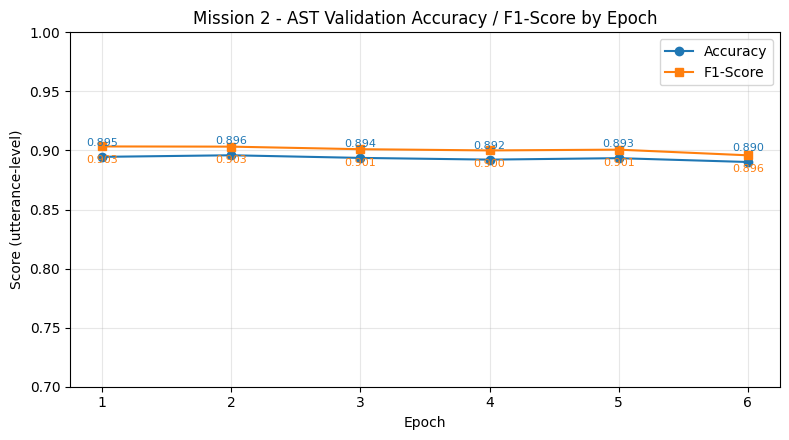

In [37]:
# ===== Epoch별 Validation Accuracy / F1-Score 그래프 (값 라벨 포함) =====
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in ast_history]
accs = [h["val_acc"] for h in ast_history]
f1s = [h["val_f1"] for h in ast_history]

plt.figure(figsize=(8, 4.5))
plt.plot(epochs, accs, marker="o", label="Accuracy")
plt.plot(epochs, f1s, marker="s", label="F1-Score")

# 각 점 위에 값 표시
for x, y in zip(epochs, accs):
    plt.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=8, color="tab:blue")
for x, y in zip(epochs, f1s):
    plt.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, -12),
                 ha="center", fontsize=8, color="tab:orange")

plt.xlabel("Epoch")
plt.ylabel("Score (utterance-level)")
plt.title("Mission 2 - AST Validation Accuracy / F1-Score by Epoch")
plt.ylim(0.70, 1.00)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("/content/mission2_metrics.png", dpi=150)
plt.show()